In [277]:
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.mps.is_available() else 'cpu')


In [278]:
# generate the random dataset
from torch.utils.data import Dataset, DataLoader

# 1. Define the Custom Dataset Class
class CustomDataset(Dataset):
    def __init__(self, nsamples=100, nfeatures=1):
        self.X = torch.randint(low=0, high=100, size=(nsamples, 1)).float()
        self.X = (self.X - self.X.mean()) / self.X.std()
        self.y = (torch.randint(low=1, high=3, size=(nsamples, 1)).float() * self.X) + torch.randint(low=1, high=10, size=(nsamples, 1)).float()
        # Generate random features (X) and binary labels (y)
        # self.X = torch.randint(low=0, high=100, size=(nsamples, 1)).float()
        # self.X = torch.randn(nsamples, nfeatures)
        # self.y = torch.randn(nsamples, 1)

        # output shape must be N x 1 = shape of m NxN * shape of x Nx1 
        # self.y = (self.X) + torch.randint(low=0, high=10, size=(nsamples, 1)).float()
        
    def __len__(self):
        # Return the total number of samples
        return len(self.X)
        
    def __getitem__(self, idx):
        # Retrieve one sample and its label by index
        sample = self.X[idx]
        label = self.y[idx]
        return sample, label

def createDataSetLoader(num_samples, num_features, batchsz):
    # Instantiate the Dataset
    my_dataset = CustomDataset(nsamples=num_samples, nfeatures=num_features)

    # Create the DataLoader
    my_dataloader = DataLoader(
        dataset=my_dataset,
        batch_size=batchsz,       # Number of samples per batch
        shuffle=False,       # Reshuffle data at every epoch
        num_workers=0        # Number of subprocesses for data loading
    )
    return (my_dataset, my_dataloader)

train_dataset, train_loader = createDataSetLoader(num_samples=1000, num_features=1, batchsz=64)

test_dataset, test_loader = createDataSetLoader(num_samples=1000, num_features=1, batchsz=64)


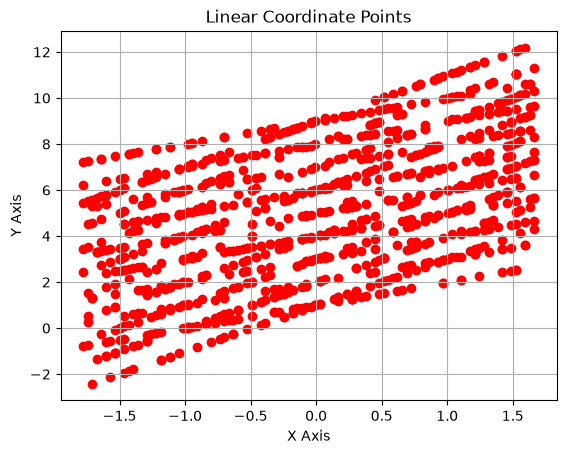

In [279]:
# Visualize the input dataset
from matplotlib import pyplot as plt

X = train_dataset.X
y = train_dataset.y

# 2. Create scatter plot
plt.scatter(X, y, color='red', marker='o')

# 3. Add labels and layout
plt.title('Linear Coordinate Points')
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.grid(True)

# 4. Display chart
plt.show()

In [280]:
from torch import optim
import torch.nn as nn

# create the simple linear regression model
linear_model = nn.Linear(in_features=1, out_features=1).to(DEVICE)

# create the SGD optimizer
sgd_optim = optim.SGD(linear_model.parameters(), lr = 0.01)


In [ ]:
# Train 1 epoch
from tqdm import tqdm as TQ

def train_one_epoch(model: nn.Linear, optimizer: optim.SGD, data_loader):

    i = 0
    model.train()
    for x, label in TQ(data_loader):
        i += 1
        x, label = x.to(DEVICE), label.to(DEVICE)
        
        # print(f'i {i} model.weight ( before y = model(x) ): {model.weight.item()}')

        y = model(x)
        # print(f'y: {y}, label: {label}')
        loss_criterion = nn.MSELoss()
        loss_output = loss_criterion(y, label)
        # print(f'loss_output: {loss_output}')

        # zero out the gradients
        optimizer.zero_grad()

        # # Check if the loss itself tracking gradients
        # print("Loss requires_grad:", loss_output.requires_grad)
        # print("Loss grad_fn:", loss_output.grad_fn)

        # # Check if your model outputs are tracking gradients
        # print("Outputs grad_fn:", outputs.grad_fn)

        # compute and backward propagate the gradients
        loss_output.backward()

        # adjust the weights
        optimizer.step()
        # print(f'model.weight ( after optimizer.step() ): {model.weight.item()}')

        # # book-keeping
        # total_loss += loss_output.item() * x.size(0) # get the batch size
        # total_samples_processed += x.size(0)

        # # preds = # It's the regression value itself

        # correct += (y == label).long().sum().item()
        # if (i == 10):
        #     break

    # avg_loss = total_loss / total_samples_processed
    # avg_accuracy = correct / total_samples_processed

    return

EPOCHS = 20
for i in range(1,EPOCHS + 1):
    train_one_epoch(model=linear_model, optimizer = sgd_optim, data_loader=train_loader)
    # print(f'avg_loss: {avg_loss}, avg_accuracy: {avg_accuracy}')

    # 5. Check what the model learned
    w, b = linear_model.weight.item(), linear_model.bias.item()
    print(f"Learned: y = {w:.2f}x + {b:.2f}  (true: y = [1-2]x + [1-10])")

# Solution using Normal equation w = (XᵀX)⁻¹ Xᵀy)
X_b = torch.cat([train_dataset.X, torch.ones(train_dataset.X.size(0), 1)], dim=1)  # add bias column
w_exact = torch.linalg.lstsq(X_b, train_dataset.y).solution
print(f'w_exact: {w_exact}')   # [weight, bias] — the mathematically optimal answer, instantly



100%|██████████| 16/16 [00:00<00:00, 898.14it/s]


Learned: y = 1.04x + 2.09  (true: y = [1-2]x + [1-10])


100%|██████████| 16/16 [00:00<00:00, 1216.20it/s]


Learned: y = 1.18x + 2.89  (true: y = [1-2]x + [1-10])


100%|██████████| 16/16 [00:00<00:00, 1287.83it/s]


...

Learned: y = 1.54x + 4.99  (true: y = [1-2]x + [1-10])


100%|██████████| 16/16 [00:00<00:00, 1272.95it/s]


Learned: y = 1.54x + 4.99  (true: y = [1-2]x + [1-10])


100%|██████████| 16/16 [00:00<00:00, 1298.27it/s]

Learned: y = 1.54x + 4.99  (true: y = [1-2]x + [1-10])
w_exact: tensor([[1.5345],
        [5.0167]])
